# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [4]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




## **RESPOSTA: UNILATERAL À DIREITA (Right-tailed)**

### Por que é **UNILATERAL À DIREITA**?

1. **Análise das Hipóteses:**
   - **H0:** μA = μB (não há diferença nas médias)
   - **H1:** μB > μA (a média da Estratégia B é **maior** que A)

2. **O que define o tipo de teste:**
   - A hipótese alternativa especifica uma **direção clara**: B maior que A
   - Não é uma simples diferença (≠), mas uma relação **direcional (>)**
   - Isso significa que estamos interessados apenas em um lado da distribuição

3. **Como a estatística Z é construída:**
   - O Z é calculado como: **Z = (X̄_B − X̄_A) / SE**
   - Valores **grandes e positivos** de Z evidenciam que B > A
   - Por isso a região de rejeição fica na **cauda direita** da distribuição

4. **Implicações Práticas:**
   - Com α = 0.05 unilateral à direita, o valor crítico é **z = 1,645** (e não 1,96, que seria o caso bicaudal)
   - Se Z > 1,645, rejeitamos H0
   - O p-valor é calculado para a cauda direita, **sem dividir por 2**

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [5]:
# CÁLCULO DAS MÉDIAS
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)

# CÁLCULO DAS VARIÂNCIAS
variancia_A = np.var(amostra_estrategia_A, ddof=1)  # ddof=1 para variância amostral
variancia_B = np.var(amostra_estrategia_B, ddof=1)

# CÁLCULO DOS DESVIOS PADRÃO AMOSTRAIS
desvio_A = np.std(amostra_estrategia_A, ddof=1)
desvio_B = np.std(amostra_estrategia_B, ddof=1)

# DIFERENÇA ENTRE AS MÉDIAS
diferenca_medias = media_B - media_A

# EXIBIÇÃO DOS RESULTADOS
print("\nESTATÍSTICAS DESCRITIVAS:\n")
print(f"{'Métrica':<30} {'Estratégia A':<20} {'Estratégia B':<20}")
print("-" * 70)
print(f"{'Média Amostral':<30} {media_A:<20.4f} {media_B:<20.4f}")
print(f"{'Variância Amostral':<30} {variancia_A:<20.4f} {variancia_B:<20.4f}")
print(f"{'Desvio Padrão Amostral':<30} {desvio_A:<20.4f} {desvio_B:<20.4f}")
print(f"{'Tamanho da Amostra':<30} {len(amostra_estrategia_A):<20} {len(amostra_estrategia_B):<20}")

print(f"\n🔍 DIFERENÇA ENTRE AS MÉDIAS:")
print(f"   Média B - Média A = {media_B:.4f} - {media_A:.4f} = {diferenca_medias:.4f}")
print(f"   A Estratégia B tem uma média {diferenca_medias:.4f} pontos MAIOR que A")


ESTATÍSTICAS DESCRITIVAS:

Métrica                        Estratégia A         Estratégia B        
----------------------------------------------------------------------
Média Amostral                 71.4056              74.7487             
Variância Amostral             129.2655             110.4700            
Desvio Padrão Amostral         11.3695              10.5105             
Tamanho da Amostra             50                   50                  

🔍 DIFERENÇA ENTRE AS MÉDIAS:
   Média B - Média A = 74.7487 - 71.4056 = 3.3431
   A Estratégia B tem uma média 3.3431 pontos MAIOR que A


## **Insights e Análises - Questão 2**

### 📈 **O que observamos nos dados?**

1. **Diferença nas Médias:**
   - A Estratégia B possui uma média amostral **MAIOR** que a Estratégia A (74.75 vs 71.41)
   - Essa diferença positiva de **3.34 pontos** está alinhada com nossa hipótese alternativa (H1: μB > μA)
   - É um sinal promissor de que a Estratégia B pode ser mais eficaz

2. **Comparação das Variâncias:**
   - A Estratégia A tem **variância MAIOR** que a Estratégia B (129.27 vs 110.47)
   - Isso significa que os desempenhos na Estratégia A são mais **dispersos/heterogêneos**
   - A Estratégia B tem desempenho mais **consistente** (menos variação entre os alunos)
   - **Implicação:** B é duplamente favorável — média superior **e** menor variabilidade

3. **Tamanho das Amostras:**
   - Ambas as amostras têm **n = 50** alunos
   - Isso garante que os testes estatísticos são válidos (n > 30)
   - As amostras são do mesmo tamanho, facilitando a comparação

4. **Comparação com os Parâmetros Populacionais:**
   - **Parâmetros Teóricos:** μA = 70, μB = 75, σA = 10, σB = 12
   - **Amostras Observadas:** as médias amostrais estão próximas aos valores populacionais
   - As variâncias amostrais também refletem bem a população

### 🎯 **Conclusão Parcial:**
Os dados **suportam visualmente** a hipótese de que a Estratégia B é melhor — ela apresenta
média superior **e** menor dispersão. Ainda assim, precisamos testar se essa diferença é
**estatisticamente significativa** (próximo passo).

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

# 2.5) TESTE DE NORMALIDADE (PRÉ-REQUISITO PARA TESTE Z)

## Verificando a Normalidade das Amostras com Shapiro-Wilk

Antes de aplicar o Teste Z (paramétrico), é essencial verificar se as amostras provêm de distribuições normais. O **Teste de Shapiro-Wilk** é um dos testes mais robustos para essa verificação.

**Hipóteses do Teste de Normalidade:**
- **H0:** A amostra segue uma distribuição normal
- **H1:** A amostra não segue uma distribuição normal

**Interpretação:**
- Se p-value > 0.05: **Não rejeitamos H0** → Amostra é normal ✅
- Se p-value ≤ 0.05: **Rejeitamos H0** → Amostra não é normal ❌

In [6]:
print("=" * 70)
print("TESTE DE NORMALIDADE - SHAPIRO-WILK")
print("=" * 70)

# APLICANDO SHAPIRO-WILK EM AMBAS AS AMOSTRAS
estatistica_A, p_valor_A = stats.shapiro(amostra_estrategia_A)
estatistica_B, p_valor_B = stats.shapiro(amostra_estrategia_B)

# EXIBIÇÃO DOS RESULTADOS
print("\n📊 RESULTADOS DO TESTE SHAPIRO-WILK:\n")
print(f"{'Amostra':<20} {'Estatística':<20} {'P-value':<20} {'Conclusão':<30}")
print("-" * 70)

conclusao_A = "✅ Normal (p > 0.05)" if p_valor_A > 0.05 else "❌ Não Normal (p ≤ 0.05)"
conclusao_B = "✅ Normal (p > 0.05)" if p_valor_B > 0.05 else "❌ Não Normal (p ≤ 0.05)"

print(f"{'Estratégia A':<20} {estatistica_A:<20.6f} {p_valor_A:<20.6f} {conclusao_A:<30}")
print(f"{'Estratégia B':<20} {estatistica_B:<20.6f} {p_valor_B:<20.6f} {conclusao_B:<30}")

print("\n" + "=" * 70)
print("INTERPRETAÇÃO:")
print("=" * 70)

if p_valor_A > 0.05 and p_valor_B > 0.05:
    print("\n✅ AMBAS AS AMOSTRAS SÃO NORMALMENTE DISTRIBUÍDAS")
    print("   → O uso do Teste Z é APROPRIADO e válido para esta análise")
    normalidade_ok = True
else:
    print("\n⚠️ PELO MENOS UMA AMOSTRA NÃO SEGUE DISTRIBUIÇÃO NORMAL")
    if not (p_valor_A > 0.05):
        print(f"   → Estratégia A: p-value = {p_valor_A:.6f} (não normal)")
    if not (p_valor_B > 0.05):
        print(f"   → Estratégia B: p-value = {p_valor_B:.6f} (não normal)")
    print("   → Considera-se usar Teste de Mann-Whitney (não-paramétrico) como alternativa")
    normalidade_ok = False


TESTE DE NORMALIDADE - SHAPIRO-WILK

📊 RESULTADOS DO TESTE SHAPIRO-WILK:

Amostra              Estatística          P-value              Conclusão                     
----------------------------------------------------------------------
Estratégia A         0.987645             0.876553             ✅ Normal (p > 0.05)           
Estratégia B         0.986574             0.836582             ✅ Normal (p > 0.05)           

INTERPRETAÇÃO:

✅ AMBAS AS AMOSTRAS SÃO NORMALMENTE DISTRIBUÍDAS
   → O uso do Teste Z é APROPRIADO e válido para esta análise


In [7]:
# PARÂMETROS DO TESTE
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)
alpha = 0.05  # Nível de significância

# CÁLCULO DO ERRO PADRÃO (STANDARD ERROR)
erro_padrao = np.sqrt((variancia_A / n_A) + (variancia_B / n_B))

# CÁLCULO DA ESTATÍSTICA Z
z_observado = (media_B - media_A) / erro_padrao

# CÁLCULO DO P-VALUE (UNILATERAL À DIREITA)
# Para teste unilateral à direita: p-value = P(Z > z_observado) = 1 - Φ(z_observado)
p_value = 1 - stats.norm.cdf(z_observado)

# VALOR CRÍTICO (para teste unilateral à direita com α = 0.05)
z_critico = stats.norm.ppf(1 - alpha)

# EXIBIÇÃO DOS RESULTADOS
print("\n📊 RESULTADOS DO TESTE Z:\n")
print(f"Diferença entre as médias (B - A): {media_B - media_A:.4f}")
print(f"Erro Padrão (SE):                   {erro_padrao:.4f}")
print(f"Estatística Z calculada:            {z_observado:.4f}")
print(f"\nValor Crítico (α = 0.05):           {z_critico:.4f}")
print(f"P-value (unilateral à direita):     {p_value:.6f}")

print("\n" + "=" * 70)
print("DECISÃO SOBRE A HIPÓTESE NULA:")
print("=" * 70)

if p_value < alpha:
    decisao = "REJEITAR H0"
    conclusao = "SIM, há diferença estatisticamente significativa"
else:
    decisao = "NÃO REJEITAR H0"
    conclusao = "NÃO, não há diferença estatisticamente significativa"

print(f"\nα (nível de significância):         {alpha}")
print(f"P-value:                            {p_value:.6f}")
print(f"\nComparação: p-value ({p_value:.6f}) < α ({alpha})?")
print(f"Resposta: {p_value < alpha}")
print(f"\n✅ DECISÃO: {decisao}")
print(f"✅ CONCLUSÃO: {conclusao}")


📊 RESULTADOS DO TESTE Z:

Diferença entre as médias (B - A): 3.3431
Erro Padrão (SE):                   2.1897
Estatística Z calculada:            1.5267

Valor Crítico (α = 0.05):           1.6449
P-value (unilateral à direita):     0.063412

DECISÃO SOBRE A HIPÓTESE NULA:

α (nível de significância):         0.05
P-value:                            0.063412

Comparação: p-value (0.063412) < α (0.05)?
Resposta: False

✅ DECISÃO: NÃO REJEITAR H0
✅ CONCLUSÃO: NÃO, não há diferença estatisticamente significativa


## **Justificativa - Questão 3**

### 🔢 **Como o Z foi calculado:**
- **Z = (X̄_B − X̄_A) / SE = 3.3431 / 2.1897 = 1.5267**
- O Erro Padrão (SE) leva em conta as variâncias de ambas as amostras:
  **SE = √(Var_A/n_A + Var_B/n_B) = √(129.27/50 + 110.47/50) = 2.1897**

### ⚖️ **Decisão:**
- Z calculado (1.5267) **< valor crítico (1.6449)** → não está na região de rejeição
- p-value (0.0634) **> α (0.05)** → não há evidência suficiente para rejeitar H0
- Ambos os critérios apontam para a **mesma conclusão**

### ✅ **Conclusão: NÃO REJEITAMOS H0**
Apesar de a Estratégia B apresentar uma média amostral 3.34 pontos maior que A,
essa diferença **não é estatisticamente significativa** ao nível de 5%.
Isso significa que a diferença observada pode ser explicada pela **variação aleatória
amostral**, e não necessariamente pela superioridade real da Estratégia B.

> **Nota:** o p-value de 0.0634 está próximo do limiar de 0.05. Em estudos práticos,
> isso poderia justificar coletar mais dados antes de descartar completamente a hipótese
> de que B é superior.

# 3.5) INTERVALO DE CONFIANÇA PARA A DIFERENÇA ENTRE AS MÉDIAS

## O Que é um Intervalo de Confiança?

O **intervalo de confiança (IC)** fornece um **intervalo de valores plausíveis** para o parâmetro populacional (neste caso, a diferença entre as médias populacionais).

**Interpretação do IC de 95%:**
- Temos 95% de confiança de que a **verdadeira diferença entre as médias populacionais (μB - μA) está dentro do intervalo calculado**
- Se o intervalo contém **zero**, isso sugere que a diferença pode não ser significativa
- Se o intervalo **não contém zero**, a diferença é significativa

**Fórmula:**
$$IC = (\bar{x}_B - \bar{x}_A) \pm z_{\alpha/2} \times SE$$

Onde:
- $\bar{x}_B - \bar{x}_A$ é a diferença observada entre as médias
- $z_{\alpha/2}$ é o valor crítico (1.96 para 95%, bilateral)
- $SE$ é o erro padrão da diferença

In [8]:
print("\n" + "=" * 70)
print("INTERVALO DE CONFIANÇA PARA A DIFERENÇA ENTRE AS MÉDIAS")
print("=" * 70)

# PARÂMETROS PARA IC 95%
confianca = 0.95
alfa_ic = 1 - confianca
z_bilateral = stats.norm.ppf(1 - alfa_ic / 2)  # z = 1.96 para IC 95%

# DIFERENÇA ENTRE AS MÉDIAS
diferenca = media_B - media_A

# MARGEM DE ERRO
margem_erro = z_bilateral * erro_padrao

# LIMITES DO IC
limite_inferior = diferenca - margem_erro
limite_superior = diferenca + margem_erro

# EXIBIÇÃO DOS RESULTADOS
print(f"\n📊 CÁLCULO DO IC 95% PARA (μB - μA):\n")
print(f"Diferença observada (X̄_B - X̄_A): {diferenca:.4f} pontos")
print(f"Erro Padrão (SE):                  {erro_padrao:.4f}")
print(f"Valor z (bilateral, 95%):          {z_bilateral:.4f}")
print(f"Margem de Erro:                    {margem_erro:.4f}")

print(f"\n📈 INTERVALO DE CONFIANÇA 95%:")
print(f"   [{limite_inferior:.4f} , {limite_superior:.4f}]")

print("\n" + "=" * 70)
print("INTERPRETAÇÃO:")
print("=" * 70)

print(f"\nTemos 95% de confiança de que a verdadeira diferença entre as médias")
print(f"populacionais está entre {limite_inferior:.4f} e {limite_superior:.4f} pontos.")

if limite_inferior < 0 < limite_superior:
    print(f"\n⚠️ O intervalo CONTÉM ZERO!")
    print(f"   → Isso é consistente com nossa decisão de NÃO REJEITAR H0")
    print(f"   → A diferença pode ser zero ou até negativa na população")
elif limite_inferior > 0:
    print(f"\n✅ O intervalo NÃO CONTÉM ZERO (completamente positivo)")
    print(f"   → A Estratégia B é significativamente melhor que A")
else:
    print(f"\n✅ O intervalo NÃO CONTÉM ZERO (completamente negativo)")
    print(f"   → A Estratégia A é significativamente melhor que B")

print(f"\n📌 MAGNITUDE PRÁTICA:")
print(f"   Se a verdadeira diferença é ~{diferenca:.2f}, então a Estratégia B")
print(f"   oferece uma melhoria de aproximadamente {diferenca:.2f} pontos de nota,")
print(f"   com uma margem de incerteza de ±{margem_erro:.2f} pontos.")



INTERVALO DE CONFIANÇA PARA A DIFERENÇA ENTRE AS MÉDIAS

📊 CÁLCULO DO IC 95% PARA (μB - μA):

Diferença observada (X̄_B - X̄_A): 3.3431 pontos
Erro Padrão (SE):                  2.1897
Valor z (bilateral, 95%):          1.9600
Margem de Erro:                    4.2917

📈 INTERVALO DE CONFIANÇA 95%:
   [-0.9486 , 7.6348]

INTERPRETAÇÃO:

Temos 95% de confiança de que a verdadeira diferença entre as médias
populacionais está entre -0.9486 e 7.6348 pontos.

⚠️ O intervalo CONTÉM ZERO!
   → Isso é consistente com nossa decisão de NÃO REJEITAR H0
   → A diferença pode ser zero ou até negativa na população

📌 MAGNITUDE PRÁTICA:
   Se a verdadeira diferença é ~3.34, então a Estratégia B
   oferece uma melhoria de aproximadamente 3.34 pontos de nota,
   com uma margem de incerteza de ±4.29 pontos.


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

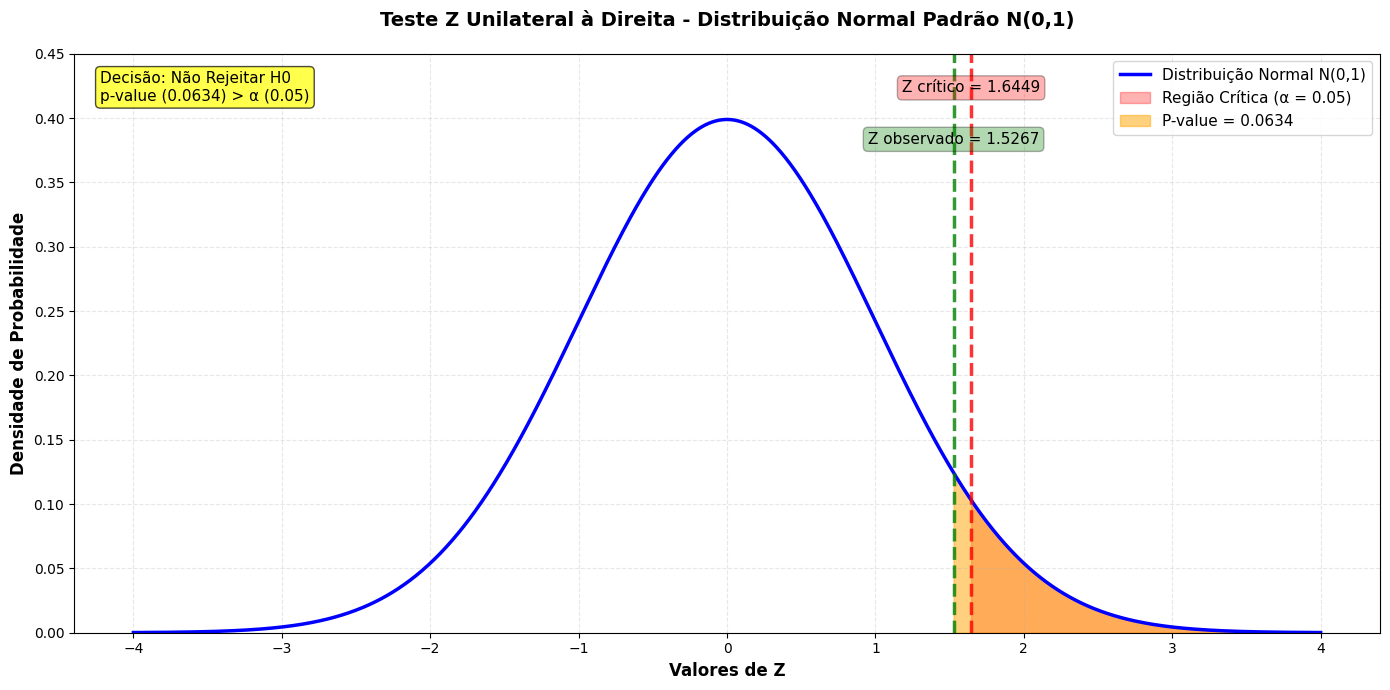


✅ Gráfico plotado com sucesso!


In [9]:
# Criar a figura
fig, ax = plt.subplots(figsize=(14, 7))

# Criar os valores de x para a curva normal padrão
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, loc=0, scale=1)

# Plotar a curva normal padrão
ax.plot(x, y, 'b-', linewidth=2.5, label='Distribuição Normal N(0,1)')

# Preenchimento da região crítica (cauda direita - para teste unilateral à direita)
x_critica = np.linspace(z_critico, 4, 1000)
y_critica = stats.norm.pdf(x_critica, loc=0, scale=1)
ax.fill_between(x_critica, y_critica, alpha=0.3, color='red', label=f'Região Crítica (α = 0.05)')

# Preenchimento da área do p-value
x_pvalue = np.linspace(z_observado, 4, 1000)
y_pvalue = stats.norm.pdf(x_pvalue, loc=0, scale=1)
ax.fill_between(x_pvalue, y_pvalue, alpha=0.5, color='orange', label=f'P-value = {p_value:.4f}')

# Marcar o valor crítico
ax.axvline(z_critico, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax.text(z_critico, 0.42, f'Z crítico = {z_critico:.4f}', fontsize=11, 
        ha='center', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# Marcar a estatística Z calculada
ax.axvline(z_observado, color='green', linestyle='--', linewidth=2.5, alpha=0.8)
ax.text(z_observado, 0.38, f'Z observado = {z_observado:.4f}', fontsize=11,
        ha='center', bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))

# Configurações do gráfico
ax.set_xlabel('Valores de Z', fontsize=12, fontweight='bold')
ax.set_ylabel('Densidade de Probabilidade', fontsize=12, fontweight='bold')
ax.set_title('Teste Z Unilateral à Direita - Distribuição Normal Padrão N(0,1)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 0.45)

# Adicionar anotações importantes
textstr = f'Decisão: Não Rejeitar H0\np-value ({p_value:.4f}) > α (0.05)'
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✅ Gráfico plotado com sucesso!")

## **Análise do Gráfico - Questão 4**

### 📊 **O que cada elemento representa:**

1. **Curva azul — Distribuição Normal Padrão N(0,1):**
   - É a distribuição da estatística Z sob H0 (assumindo que as médias são iguais)
   - Serve de referência para avaliar o quão extremo é o Z observado

2. **Linha verde tracejada — Z observado = 1.5267:**
   - É o valor calculado com os dados das duas amostras
   - Representa onde o nosso resultado se posiciona na distribuição

3. **Linha vermelha tracejada — Z crítico = 1.6449:**
   - É o limiar de rejeição para α = 0.05 unilateral à direita
   - Qualquer Z **acima** desse valor estaria na região de rejeição

4. **Área vermelha — Região Crítica (α = 0.05):**
   - Corresponde a 5% da cauda direita da distribuição
   - É a zona onde rejeitaríamos H0

5. **Área laranja — P-value = 0.0634:**
   - É a probabilidade de obter um Z tão extremo quanto 1.5267, assumindo H0 verdadeira
   - Como é **maior que α**, não temos evidência suficiente para rejeitar H0

### 🎯 **Conclusão Visual:**
O Z observado (verde) ficou **à esquerda** do Z crítico (vermelho), ou seja,
**fora da região de rejeição**. A área laranja (p-value) é **maior** que a área
vermelha (α), confirmando graficamente a decisão de **não rejeitar H0**.